
Total DASS Questions: 42

Remaining after variance filtering: 42


C:\Users\Ali\AppData\Local\Temp\ipykernel_8492\1552945873.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DASS_TOTAL'] = X.sum(axis=1)



Nodes: 42
Edges: 861

Top Important Questions:

   Question  Centrality
12     Q13A    0.026899
33     Q34A    0.025960
20     Q21A    0.025945
25     Q26A    0.025880
16     Q17A    0.025758
37     Q38A    0.025436
10     Q11A    0.025367
35     Q36A    0.025344
2       Q3A    0.025272
32     Q33A    0.025246
27     Q28A    0.025201
28     Q29A    0.025154
9      Q10A    0.025153
0       Q1A    0.025131
4       Q5A    0.025119
15     Q16A    0.025048
7       Q8A    0.025009
23     Q24A    0.024959
19     Q20A    0.024863
11     Q12A    0.024749
Top 5 Questions => R2: 0.7408 | MAE: 12.1277
Top 6 Questions => R2: 0.7380 | MAE: 12.2002
Top 7 Questions => R2: 0.7876 | MAE: 10.9260
Top 8 Questions => R2: 0.8272 | MAE: 9.7792
Top 9 Questions => R2: 0.8408 | MAE: 9.4243
Top 10 Questions => R2: 0.8795 | MAE: 8.1727
Top 11 Questions => R2: 0.8988 | MAE: 7.4984
Top 12 Questions => R2: 0.9099 | MAE: 7.0809
Top 13 Questions => R2: 0.9163 | MAE: 6.8015
Top 14 Questions => R2: 0.9238 | MAE: 6.4869

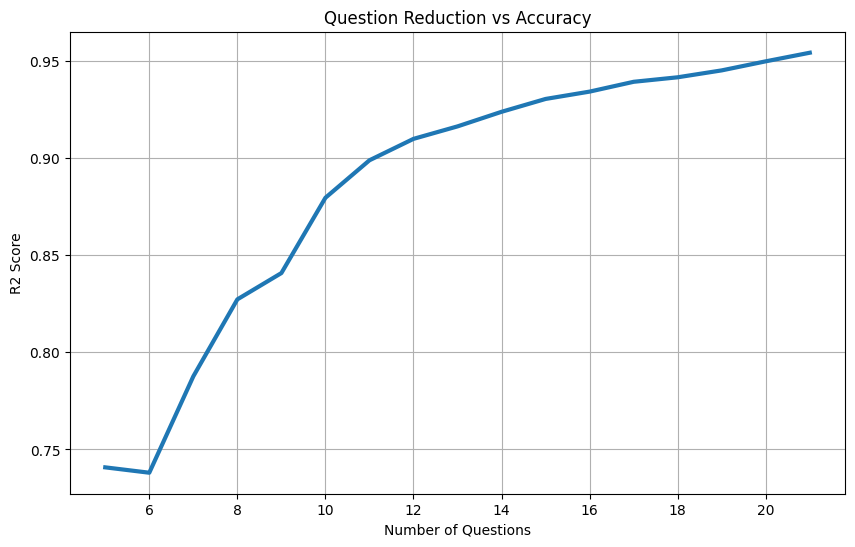

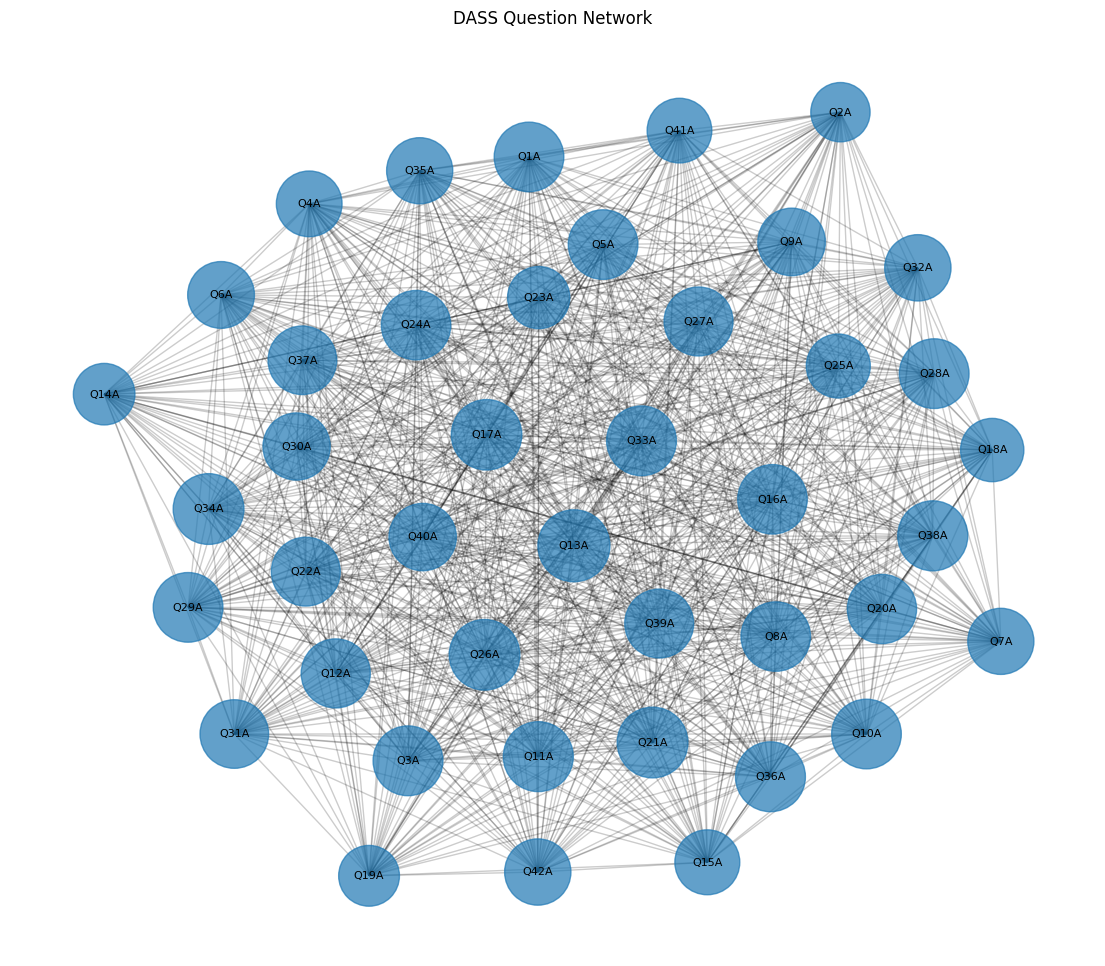

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor

# =========================================
# 1. Load Dataset
# =========================================

file_path = "DASS42-TIPI.csv"

df = pd.read_csv(
    file_path,
    engine='python',
    on_bad_lines='skip'
)


dass_questions = [
    col for col in df.columns
    if col.startswith('Q') and col.endswith('A')
]

print(f"\nTotal DASS Questions: {len(dass_questions)}")

X = df[dass_questions].copy()

# =========================================
# 3. Numeric conversion
# =========================================

X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
df = df.loc[X.index]

df['DASS_TOTAL'] = X.sum(axis=1)

y = df['DASS_TOTAL']

# =========================================
# 6. Scaling
# =========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# =========================================
# 7. Variance Filtering
# =========================================

selector = VarianceThreshold(
    threshold=0.01
)

X_var = selector.fit_transform(X_scaled)

selected_cols = X_scaled.columns[
    selector.get_support()
]

X_var = pd.DataFrame(
    X_var,
    columns=selected_cols
)

print(f"\nRemaining after variance filtering: {len(selected_cols)}")

# =========================================
# 8. Correlation Matrix
# =========================================

corr_matrix = X_var.corr().abs()

# =========================================
# 9. Build Network
# =========================================

threshold = 0.15

G = nx.Graph()

for col in corr_matrix.columns:
    G.add_node(col)

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if corr_value >= threshold:

            G.add_edge(
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                weight=corr_value
            )

print("\nNodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# =========================================
# 10. PageRank Centrality
# =========================================

centrality = nx.pagerank(
    G,
    alpha=0.85
)

centrality_df = pd.DataFrame({
    'Question': list(centrality.keys()),
    'Centrality': list(centrality.values())
})

centrality_df = centrality_df.sort_values(
    by='Centrality',
    ascending=False
)

print("\nTop Important Questions:\n")
print(centrality_df.head(20))


TARGET_R2 = 0.95

results = []

best_questions = None

for top_k in range(5, len(centrality_df)+1):

    selected_questions = centrality_df.head(top_k)[
        'Question'
    ].tolist()

    X_selected = X[selected_questions]

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    results.append({
        'Questions': top_k,
        'R2': r2,
        'MAE': mae
    })

    print(
        f"Top {top_k} Questions "
        f"=> R2: {r2:.4f} | "
        f"MAE: {mae:.4f}"
    )

    if r2 >= TARGET_R2:

        best_questions = selected_questions

        print("\n===================================")
        print("TARGET ACCURACY REACHED")
        print("===================================")

        print(f"\nMinimum Questions Needed: {top_k}")
        print(f"R2 Score: {r2:.4f}")

        break


print("\nSelected Reduced Questions:\n")

for q in best_questions:
    print(q)


reduced_df = df[best_questions]

reduced_df.to_csv(
    "DASS_reduced.csv",
    index=False
)

print("\nReduced dataset saved.")


results_df = pd.DataFrame(results)

plt.figure(figsize=(10,6))

plt.plot(
    results_df['Questions'],
    results_df['R2'],
    linewidth=3
)

plt.xlabel("Number of Questions")

plt.ylabel("R2 Score")

plt.title("Question Reduction vs Accuracy")

plt.grid(True)

plt.show()


plt.figure(figsize=(14,12))

pos = nx.spring_layout(
    G,
    seed=42
)

node_sizes = [
    centrality[node] * 100000
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("DASS Question Network")

plt.axis('off')

plt.show()